In [31]:
import yfinance as yf
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

In [32]:
spy = yf.Ticker("SPY")   # SPDR S&P 500 ETF
voo = yf.Ticker("VOO")   # Vanguard S&P 500 ETF
ivv = yf.Ticker("IVV")   # iShares Core S&P 500 ETF

In [33]:
data = yf.download("SPY", start="2020-01-01", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [34]:
# closing price only
spy_close = data["Close"]
spy_close.columns.name = None   # drop the "Ticker" column label
spy_close = spy_close.rename(columns={"SPY": "close"})
spy_close.tail()

,close
Date,
2026-09-09,762.400024
2026-09-10,757.830017
2026-09-11,764.289978
2026-09-14,760.880005
2026-09-15,757.390015


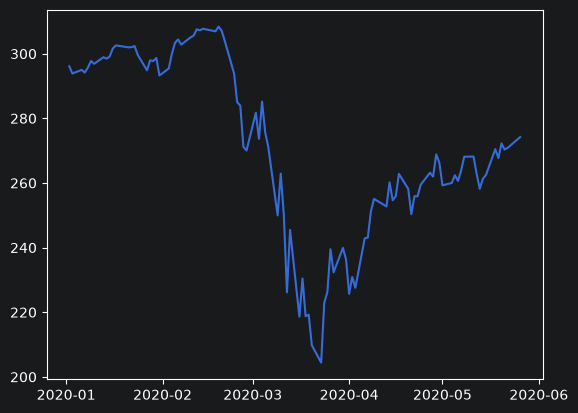

In [35]:
plt.plot(spy_close[:100])

In [36]:
# 1. moving average and standard deviation of the trailing window (historical, excludes today)
window = 7
num_std = 1

sig = spy_close.copy()
sig["ma"] = sig["close"].rolling(window).mean().shift(1)
sig["std"] = sig["close"].rolling(window).std().shift(1)
sig["upper"] = sig["ma"] + num_std * sig["std"]
sig["lower"] = sig["ma"] - num_std * sig["std"]

# 2. is today's close outside the historical range?
sig["signal"] = 0
sig.loc[sig["close"] < sig["lower"], "signal"] = 1    # underpriced -> buy now, sell tomorrow
sig.loc[sig["close"] > sig["upper"], "signal"] = -1   # overpriced  -> sell now, buy tomorrow
sig = sig.dropna()

sig["signal"].value_counts()

signal
-1    663
 0    658
 1    356
Name: count, dtype: int64

In [37]:
# 3/4. each signal is a one-day trade: enter at today's close, exit at tomorrow's close
starting_cash = 10_000

trades = sig[["close", "signal"]].copy()
trades["exit_close"] = trades["close"].shift(-1)
trades = trades.dropna()

equity = starting_cash
rows = []
for date, row in trades.iterrows():
    shares = 0
    pnl = 0.0
    if row["signal"] != 0:
        shares = int(equity // row["close"])                            # size with all available equity
        pnl = row["signal"] * shares * (row["exit_close"] - row["close"])  # long: exit-entry, short: entry-exit
        equity += pnl
    rows.append({"signal": row["signal"], "entry": row["close"], "exit": row["exit_close"],
                 "shares": shares, "trade_pnl": pnl, "equity": equity})

portfolio = pd.DataFrame(rows, index=trades.index)
portfolio["pnl"] = portfolio["equity"] - starting_cash
portfolio["side"] = portfolio["signal"].map({1: "long", -1: "short", 0: ""})
portfolio[portfolio["signal"] != 0].tail(10)

,signal,entry,exit,shares,trade_pnl,equity,pnl,side
Date,,,,,,,,
2026-08-19,1.0,769.059998,762.599976,17,-109.820374,12964.778946,2964.778946,long
2026-08-20,1.0,762.599976,765.719971,17,53.039917,13017.818863,3017.818863,long
2026-08-21,1.0,765.719971,763.469971,17,-38.250000,12979.568863,2979.568863,long
2026-08-24,1.0,763.469971,765.909973,17,41.480042,13021.048904,3021.048904,long
2026-08-27,-1.0,771.099976,769.349976,16,28.000000,13049.048904,3049.048904,short
2026-08-28,-1.0,769.349976,767.049988,16,36.799805,13085.848709,3085.848709,short
2026-09-01,1.0,761.780029,765.159973,17,57.459045,13143.307755,3143.307755,long
2026-09-03,-1.0,773.169983,770.190002,16,47.679688,13190.987442,3190.987442,short
2026-09-09,1.0,762.400024,757.830017,17,-77.690125,13113.297318,3113.297318,long


In [38]:
done = portfolio[portfolio["signal"] != 0]
wins = done[done["trade_pnl"] > 0]
daily_ret = portfolio["equity"].pct_change().dropna()
drawdown = portfolio["equity"] / portfolio["equity"].cummax() - 1
buy_hold = starting_cash * (portfolio.index.map(sig["close"])[-1] / sig["close"].iloc[0])

print(f"starting cash:   ${starting_cash:,.2f}")
print(f"final equity:    ${portfolio['equity'].iloc[-1]:,.2f}  ({portfolio['pnl'].iloc[-1] / starting_cash:+.2%})")
print(f"buy & hold:      ${buy_hold:,.2f}  ({buy_hold / starting_cash - 1:+.2%})")
print(f"trades:          {len(done)}  (long {int((done['signal'] == 1).sum())}, short {int((done['signal'] == -1).sum())})")
print(f"win rate:        {len(wins) / len(done):.1%}")
print(f"avg trade pnl:   ${done['trade_pnl'].mean():,.2f}")
print(f"  long avg:      ${done.loc[done['signal'] == 1, 'trade_pnl'].mean():,.2f}")
print(f"  short avg:     ${done.loc[done['signal'] == -1, 'trade_pnl'].mean():,.2f}")
print(f"max drawdown:    {drawdown.min():.2%}")
print(f"sharpe (daily):  {daily_ret.mean() / daily_ret.std() * np.sqrt(252):.2f}")

starting cash:   $10,000.00
final equity:    $13,223.12  (+32.23%)
buy & hold:      $25,453.22  (+154.53%)
trades:          1018  (long 355, short 663)
win rate:        49.1%
avg trade pnl:   $3.17
  long avg:      $20.47
  short avg:     $-6.10
max drawdown:    -15.18%
sharpe (daily):  0.36


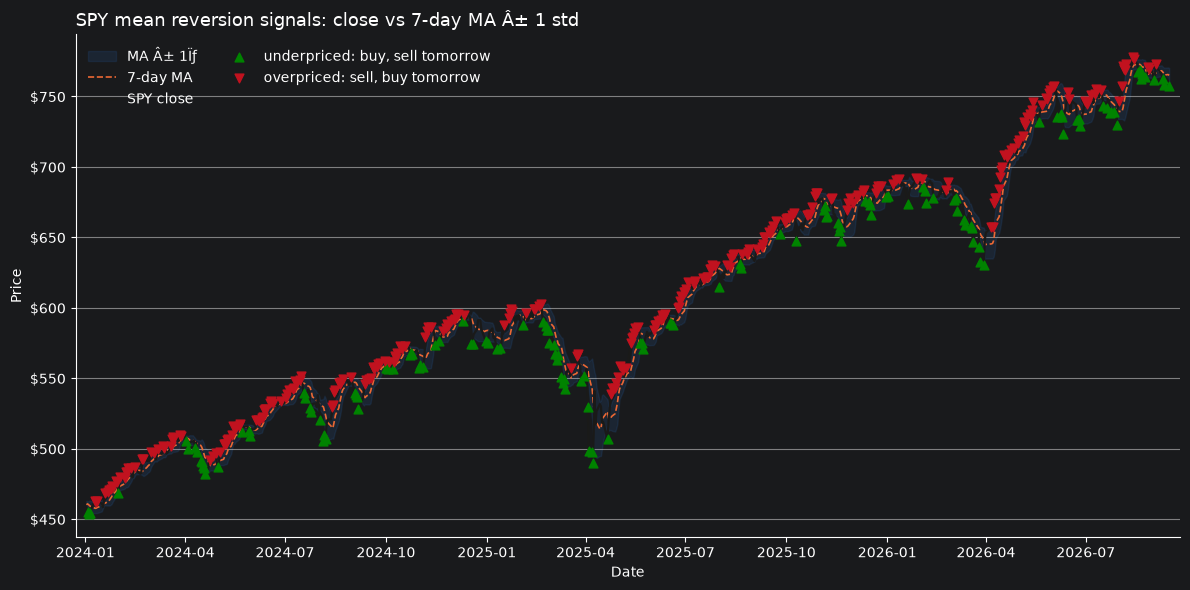

In [39]:
plot = sig.loc["2024-01-01":]

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(plot.index, plot["lower"], plot["upper"], color="#2a78d6", alpha=0.12, label=f"MA Â± {num_std}Ïƒ")
ax.plot(plot.index, plot["ma"], color="#eb6834", linewidth=1.2, linestyle="--", label=f"{window}-day MA")
ax.plot(plot.index, plot["close"], color="#1a1a19", linewidth=1.6, label="SPY close")

under, over = plot[plot["signal"] == 1], plot[plot["signal"] == -1]
ax.scatter(under.index, under["close"], marker="^", s=40, color="#008300", zorder=3, label="underpriced: buy, sell tomorrow")
ax.scatter(over.index, over["close"], marker="v", s=40, color="#c1121f", zorder=3, label="overpriced: sell, buy tomorrow")

ax.set_title(f"SPY mean reversion signals: close vs {window}-day MA Â± {num_std} std", fontsize=13, loc="left")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False, ncol=2)
ax.margins(x=0.01)
fig.tight_layout()
plt.show()

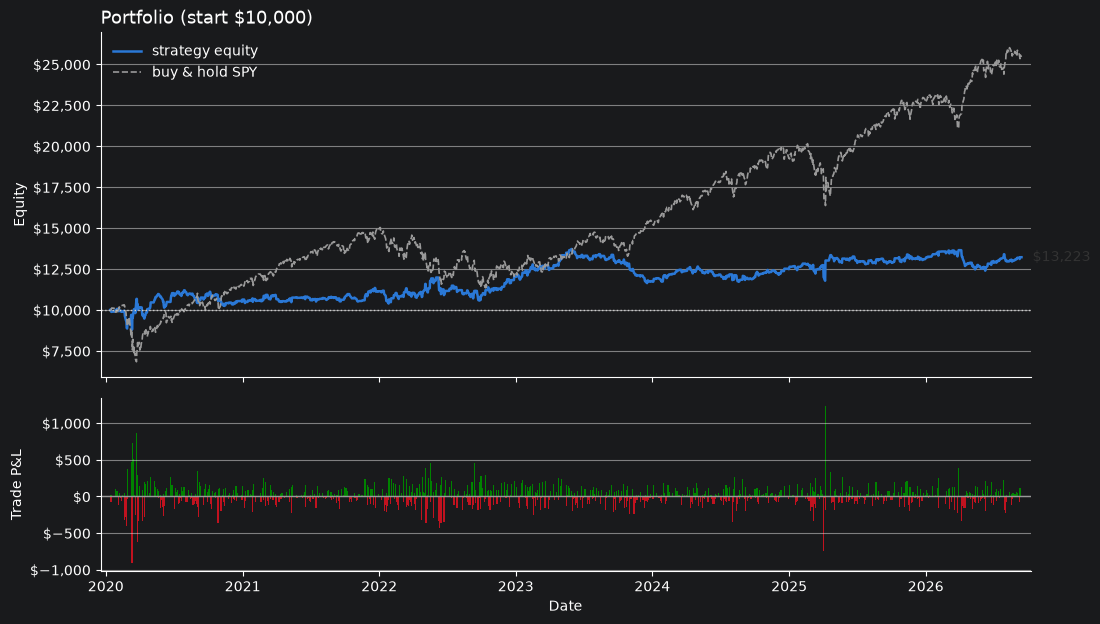

In [40]:
bh = starting_cash * sig["close"].loc[portfolio.index] / sig["close"].loc[portfolio.index].iloc[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})

ax1.plot(portfolio.index, portfolio["equity"], color="#2a78d6", linewidth=1.8, label="strategy equity")
ax1.plot(bh.index, bh, color="#999999", linewidth=1.2, linestyle="--", label="buy & hold SPY")
ax1.axhline(starting_cash, color="#cccccc", linewidth=1, linestyle=":")
ax1.annotate(f"${portfolio['equity'].iloc[-1]:,.0f}", xy=(portfolio.index[-1], portfolio["equity"].iloc[-1]),
             xytext=(8, 0), textcoords="offset points", va="center", fontsize=10, color="#333333")
ax1.set_title("Portfolio (start $10,000)", fontsize=13, loc="left")
ax1.set_ylabel("Equity")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("${x:,.0f}"))
ax1.legend(loc="upper left", frameon=False)

colors = np.where(done["trade_pnl"] >= 0, "#008300", "#c1121f")
ax2.bar(done.index, done["trade_pnl"], color=colors, width=3)
ax2.axhline(0, color="#999999", linewidth=1)
ax2.set_ylabel("Trade P&L")
ax2.set_xlabel("Date")
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("${x:,.0f}"))

for ax in (ax1, ax2):
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.01)

plt.show()

## Strategy 2: limit-order exit

Same signal, different exit. Underpriced → buy at today's close and place a **limit sell at today's upper band** (MA + 1σ). Overpriced → sell at today's close and place a **limit buy at today's lower band** (MA − 1σ). The limit level is fixed on the signal day; the order fills at that price on the first day the close trades through it. The order is kept alive for **7 trading days**; if it hasn't filled by then the position is closed at that day's close. One position at a time — new signals are ignored while an order is working.

In [41]:
max_hold = 7   # order lives for 7 trading days; if the limit has not filled by then, close at that day's close

cash = starting_cash
position = 0        # +shares long, -shares short
limit = None        # working order price
entry_px = entry_date = None
trade_log, rows = [], []

for date, row in sig.iterrows():
    close = row["close"]

    # --- manage the open position first ---
    if position != 0:
        days_held = sig.index.get_loc(date) - sig.index.get_loc(entry_date)   # trading days, same units as `window`
        filled = (position > 0 and close >= limit) or (position < 0 and close <= limit)
        timed_out = max_hold is not None and days_held >= max_hold
        if filled or timed_out:
            exit_px = limit if filled else close       # limit fills at the limit price, timeout at the close
            cash += position * exit_px
            trade_log.append({"entry_date": entry_date, "exit_date": date, "side": "long" if position > 0 else "short",
                              "entry": entry_px, "exit": exit_px, "limit": limit, "shares": abs(position),
                              "trade_pnl": position * (exit_px - entry_px), "days_held": days_held,
                              "exit_reason": "limit" if filled else "timeout"})
            position, limit = 0, None

    # --- new signal (only when flat) ---
    if position == 0 and row["signal"] != 0:
        shares = int(cash // close)
        if shares > 0:
            position = int(row["signal"]) * shares
            cash -= position * close
            entry_px, entry_date = close, date
            limit = row["upper"] if row["signal"] == 1 else row["lower"]   # fixed from the signal day's band

    rows.append({"close": close, "position": position, "cash": cash, "limit": limit,
                 "equity": cash + position * close})

portfolio2 = pd.DataFrame(rows, index=sig.index)
portfolio2["pnl"] = portfolio2["equity"] - starting_cash
trades2 = pd.DataFrame(trade_log)
trades2.tail(10)

,entry_date,exit_date,side,entry,exit,limit,shares,trade_pnl,days_held,exit_reason
243,2026-06-30,2026-07-10,short,746.770020,754.950012,730.864063,8,-65.439941,7,timeout
244,2026-07-10,2026-07-17,short,754.950012,744.822080,744.822080,8,81.023460,5,limit
245,2026-07-17,2026-07-28,long,743.289978,740.859985,754.537174,8,-19.439941,7,timeout
246,2026-07-29,2026-07-31,long,729.460022,746.251163,746.251163,8,134.329128,2,limit
247,2026-07-31,2026-08-11,short,747.030029,770.559998,734.017992,8,-188.239746,7,timeout
248,2026-08-13,2026-08-18,short,777.880005,769.528551,769.528551,7,58.460176,3,limit
249,2026-08-18,2026-08-27,long,767.450012,771.099976,776.245607,8,29.199707,7,timeout
250,2026-08-27,2026-09-01,short,771.099976,763.553337,763.553337,8,60.373111,3,limit
251,2026-09-01,2026-09-03,long,761.780029,769.485873,769.485873,8,61.646746,2,limit
252,2026-09-03,2026-09-09,short,773.169983,763.631198,763.631198,8,76.310280,3,limit


In [42]:
wins2 = trades2[trades2["trade_pnl"] > 0]
daily_ret2 = portfolio2["equity"].pct_change().dropna()
drawdown2 = portfolio2["equity"] / portfolio2["equity"].cummax() - 1
open_pos = int(portfolio2["position"].iloc[-1])

print(f"starting cash:   ${starting_cash:,.2f}")
print(f"final equity:    ${portfolio2['equity'].iloc[-1]:,.2f}  ({portfolio2['pnl'].iloc[-1] / starting_cash:+.2%})")
print(f"strategy 1:      ${portfolio['equity'].iloc[-1]:,.2f}  ({portfolio['pnl'].iloc[-1] / starting_cash:+.2%})")
print(f"trades:          {len(trades2)}  (long {int((trades2['side'] == 'long').sum())}, short {int((trades2['side'] == 'short').sum())})")
print(f"win rate:        {len(wins2) / len(trades2):.1%}")
print(f"avg trade pnl:   ${trades2['trade_pnl'].mean():,.2f}")
print(f"avg days held:   {trades2['days_held'].mean():.1f}  (max {trades2['days_held'].max()})")
print(f"open position:   {open_pos:+d} shares" + (f" (limit ${portfolio2['limit'].iloc[-1]:.2f})" if open_pos else ""))
print(f"max drawdown:    {drawdown2.min():.2%}")
print(f"sharpe (daily):  {daily_ret2.mean() / daily_ret2.std() * np.sqrt(252):.2f}")

starting cash:   $10,000.00
final equity:    $6,376.10  (-36.24%)
strategy 1:      $13,223.12  (+32.23%)
trades:          253  (long 104, short 149)
win rate:        50.2%
avg trade pnl:   $-14.17
avg days held:   6.1  (max 7)
open position:   +8 shares (limit $771.25)
max drawdown:    -45.79%
sharpe (daily):  -0.28


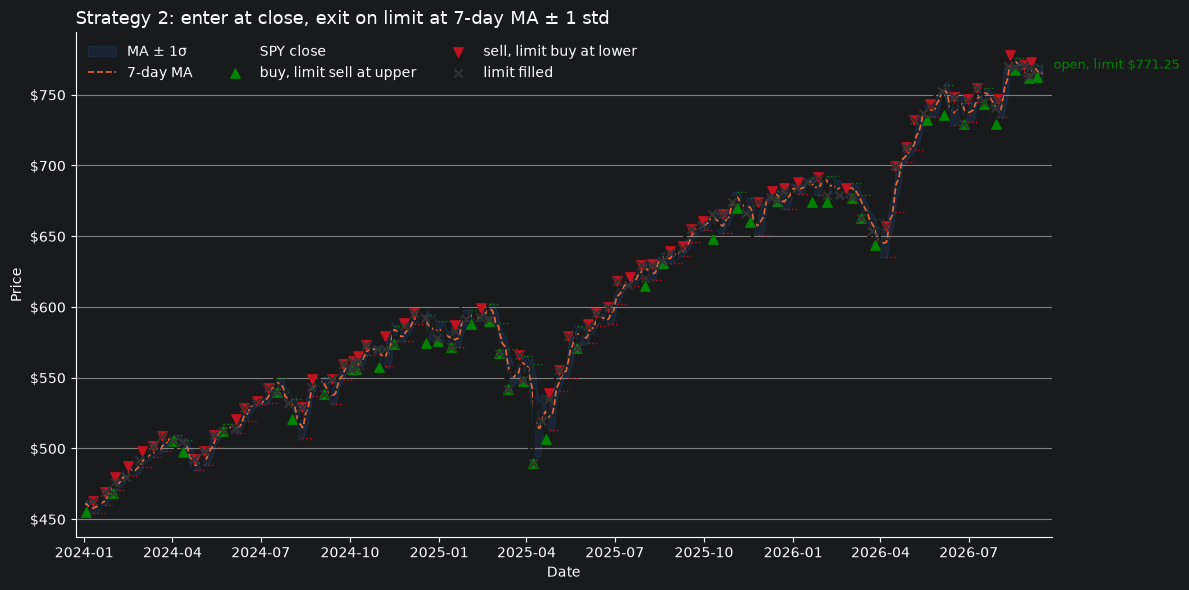

In [43]:
plot = sig.loc["2024-01-01":]
t = trades2[trades2["entry_date"] >= plot.index[0]]

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(plot.index, plot["lower"], plot["upper"], color="#2a78d6", alpha=0.12, label=f"MA ± {num_std}σ")
ax.plot(plot.index, plot["ma"], color="#eb6834", linewidth=1.2, linestyle="--", label=f"{window}-day MA")
ax.plot(plot.index, plot["close"], color="#1a1a19", linewidth=1.6, label="SPY close")

for _, tr in t.iterrows():
    c = "#008300" if tr["side"] == "long" else "#c1121f"
    ax.hlines(tr["limit"], tr["entry_date"], tr["exit_date"], color=c, linewidth=1, linestyle=":")  # working limit order
longs, shorts = t[t["side"] == "long"], t[t["side"] == "short"]
ax.scatter(longs["entry_date"], longs["entry"], marker="^", s=45, color="#008300", zorder=3, label="buy, limit sell at upper")
ax.scatter(shorts["entry_date"], shorts["entry"], marker="v", s=45, color="#c1121f", zorder=3, label="sell, limit buy at lower")
ax.scatter(t["exit_date"], t["exit"], marker="x", s=35, color="#333333", zorder=3, label="limit filled")

# still-open position: entry marker + working limit through the end of the data
if position != 0 and entry_date >= plot.index[0]:
    c = "#008300" if position > 0 else "#c1121f"
    ax.scatter([entry_date], [entry_px], marker="^" if position > 0 else "v", s=45, color=c, zorder=3)
    ax.hlines(limit, entry_date, plot.index[-1], color=c, linewidth=1, linestyle=":")
    ax.annotate(f"open, limit ${limit:.2f}", xy=(plot.index[-1], limit), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9, color=c)

ax.set_title(f"Strategy 2: enter at close, exit on limit at {window}-day MA ± {num_std} std", fontsize=13, loc="left")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False, ncol=3)
ax.margins(x=0.01)
fig.tight_layout()
plt.show()

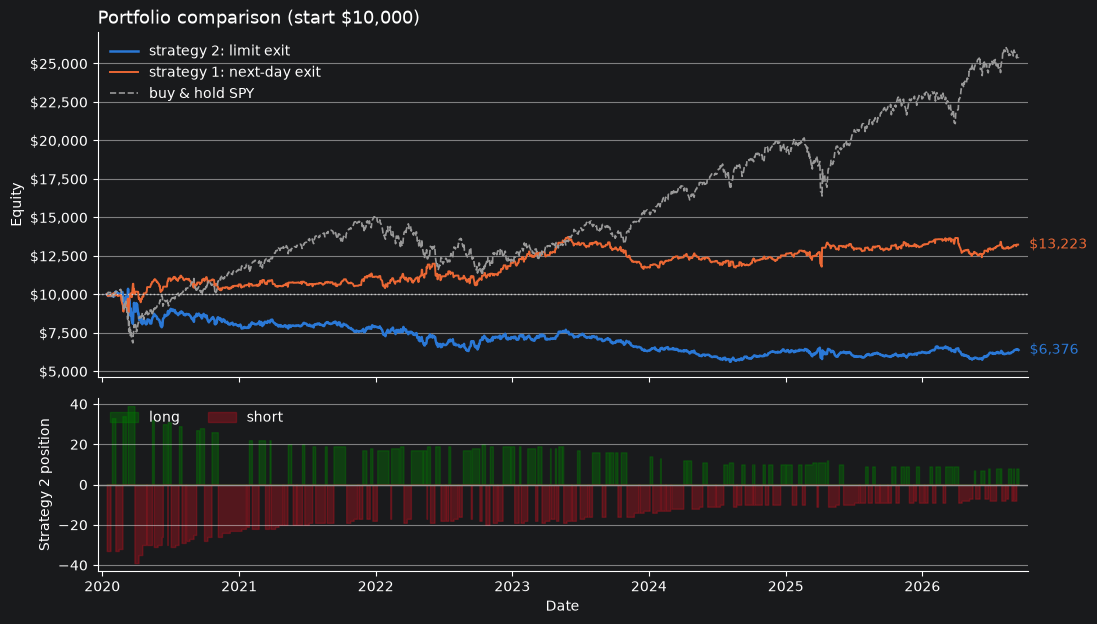

In [44]:
bh = starting_cash * sig["close"] / sig["close"].iloc[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})

ax1.plot(portfolio2.index, portfolio2["equity"], color="#2a78d6", linewidth=1.8, label="strategy 2: limit exit")
ax1.plot(portfolio.index, portfolio["equity"], color="#eb6834", linewidth=1.4, label="strategy 1: next-day exit")
ax1.plot(bh.index, bh, color="#999999", linewidth=1.2, linestyle="--", label="buy & hold SPY")
ax1.axhline(starting_cash, color="#cccccc", linewidth=1, linestyle=":")
for s, c in ((portfolio2, "#2a78d6"), (portfolio, "#eb6834")):
    ax1.annotate(f"${s['equity'].iloc[-1]:,.0f}", xy=(s.index[-1], s["equity"].iloc[-1]),
                 xytext=(8, 0), textcoords="offset points", va="center", fontsize=10, color=c)
ax1.set_title("Portfolio comparison (start $10,000)", fontsize=13, loc="left")
ax1.set_ylabel("Equity")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("${x:,.0f}"))
ax1.legend(loc="upper left", frameon=False)

ax2.fill_between(portfolio2.index, 0, portfolio2["position"].clip(lower=0), step="post", color="#008300", alpha=0.35, label="long")
ax2.fill_between(portfolio2.index, 0, portfolio2["position"].clip(upper=0), step="post", color="#c1121f", alpha=0.35, label="short")
ax2.axhline(0, color="#999999", linewidth=1)
ax2.set_ylabel("Strategy 2 position")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left", frameon=False, ncol=2)

for ax in (ax1, ax2):
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.01)

plt.show()